# Projekt Klasyfikacji uczniow

# import bibliotek


In [2]:
# import wszytskich potrzebnych bibliotek
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error

# Eksploracja danych

In [3]:
data = pd.read_csv('data/Student_performance_data.csv', index_col='IDStudenta', names=["IDStudenta", "Wiek", "Plec", "Pochodzenie", "WyksztalcenieRodzica", "CzasSpedzonyNaNauceTyg.", "Nieobecnosci", "Tutoring", "WsparcieRodzicow", "ZajeciaPozalekcyjne", "Sport", "Muzyka", "Wolontariat", "SredniaKoncowa"], header=0)

print("Mamy", data.shape[0], "wierszy i", data.shape[1], "kolumn")
data.head()


Mamy 2392 wierszy i 13 kolumn


,Wiek,Plec,Pochodzenie,WyksztalcenieRodzica,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,WsparcieRodzicow,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
IDStudenta,,,,,,,,,,,,,
1001,21,Female,Caucasian,Some College,19.833723,7,Yes,Moderate,0,0,1,0,4.20
1002,22,Male,Caucasian,High School,15.408756,0,No,Low,0,0,0,0,4.28
1003,19,Male,Asian,Bachelor's,4.210570,26,No,Moderate,0,0,0,0,2.08
1004,21,Female,Caucasian,Bachelor's,10.028829,14,No,High,1,0,0,0,3.54
1005,21,Female,Caucasian,Some College,4.672495,17,Yes,High,0,0,0,0,2.97


In [4]:
data.describe()

,Wiek,CzasSpedzonyNaNauceTyg.,Nieobecnosci,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
count,2392.000000,2389.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,20.468645,9.773029,14.541388,0.383361,0.303512,0.196906,0.157191,3.429603
std,1.123798,5.652477,8.467417,0.486307,0.459870,0.397744,0.364057,0.686363
min,19.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,19.000000,5.043640,7.000000,0.000000,0.000000,0.000000,0.000000,2.880000
50%,20.000000,9.705614,15.000000,0.000000,0.000000,0.000000,0.000000,3.420000
75%,21.000000,14.408321,22.000000,1.000000,1.000000,0.000000,0.000000,3.970000
max,22.000000,19.978094,29.000000,1.000000,1.000000,1.000000,1.000000,5.000000


Wnioski:
- Widzimy ze wartosci sa w formacie tekstowym a powinny byc numeryczne aby modele lepiej dzialaly
- kolumna z 'srednia' nie jest zaokraglona

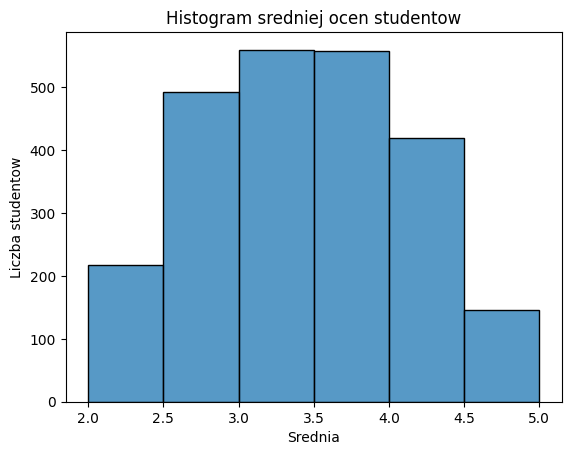

In [5]:
sns.histplot(data['SredniaKoncowa'], bins=6)
plt.xlabel('Srednia')
plt.ylabel('Liczba studentow')
plt.title('Histogram sredniej ocen studentow')
plt.show()

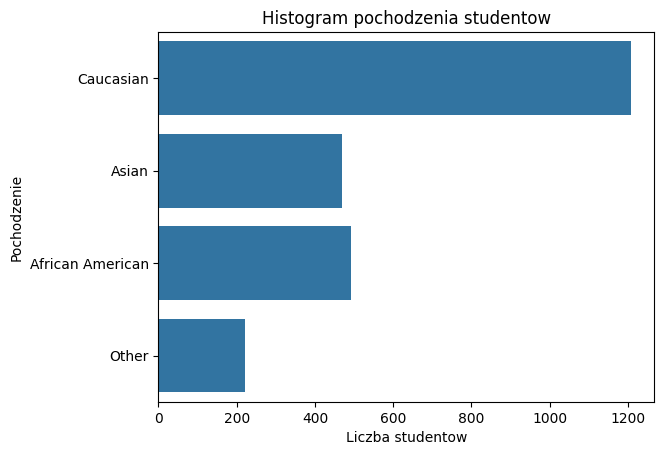

In [6]:
sns.countplot(data['Pochodzenie'])
plt.xlabel('Liczba studentow')
plt.ylabel('Pochodzenie')
plt.title('Histogram pochodzenia studentow')
plt.show()


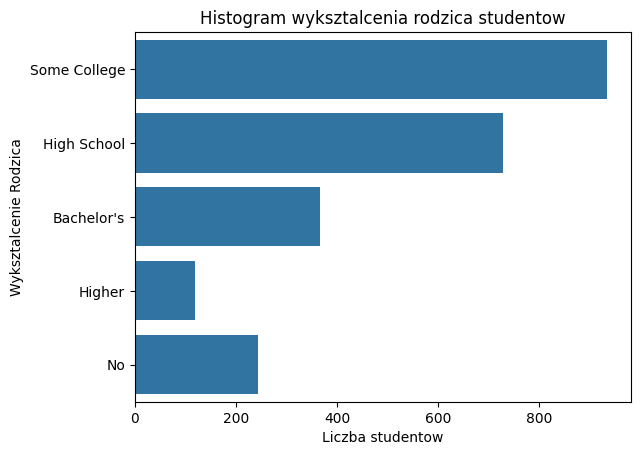

In [7]:
sns.countplot(data['WyksztalcenieRodzica'])
plt.xlabel('Liczba studentow')
plt.ylabel('Wyksztalcenie Rodzica')
plt.title('Histogram wyksztalcenia rodzica studentow')
plt.show()

# Preprocessing danych

## Uzupelnieie brakujacych wartosci

In [8]:
print(data.isnull().sum()[data.isnull().sum() > 0])
print("Widzimy rownież że mamy brakujacych wartosci ktore nalezy uzupełnić")
data['CzasSpedzonyNaNauceTyg.'] = data['CzasSpedzonyNaNauceTyg.'].fillna(data['CzasSpedzonyNaNauceTyg.'].mean())
print(data.isnull().sum()[data.isnull().sum() > 0])

CzasSpedzonyNaNauceTyg.    3
dtype: int64
Widzimy rownież że mamy brakujacych wartosci ktore nalezy uzupełnić
Series([], dtype: int64)


Uzupelniamy na podstawie wartosci sredniej czasu spedznego na nauce Tygodniowo

## zamiana Wartosci tekstowych na numeryczne

In [9]:
labelEncoder = LabelEncoder()
data['Plec'] = labelEncoder.fit_transform(data['Plec']) # Female -> 0 Male ->1
data['Tutoring'] = labelEncoder.fit_transform(data['Tutoring']) # No -> 0 Yes -> 1

data.head()

,Wiek,Plec,Pochodzenie,WyksztalcenieRodzica,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,WsparcieRodzicow,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
IDStudenta,,,,,,,,,,,,,
1001,21,0,Caucasian,Some College,19.833723,7,1,Moderate,0,0,1,0,4.20
1002,22,1,Caucasian,High School,15.408756,0,0,Low,0,0,0,0,4.28
1003,19,1,Asian,Bachelor's,4.210570,26,0,Moderate,0,0,0,0,2.08
1004,21,0,Caucasian,Bachelor's,10.028829,14,0,High,1,0,0,0,3.54
1005,21,0,Caucasian,Some College,4.672495,17,1,High,0,0,0,0,2.97


In [10]:
oneHotEncoder = OneHotEncoder(sparse_output=False, drop='first')
oneHotEncoder2 = OneHotEncoder(sparse_output=False, drop='first')
oneHotEncoder3 = OneHotEncoder(sparse_output=False, drop='first')
pochodzenieMatrix = oneHotEncoder.fit_transform(data[['Pochodzenie']])
wyksztalcenieMatrix = oneHotEncoder2.fit_transform(data[['WyksztalcenieRodzica']])
wsparcieRodzicowMatrix = oneHotEncoder3.fit_transform(data[['WsparcieRodzicow']])

pochodzenieDF = pd.DataFrame(pochodzenieMatrix, columns=oneHotEncoder.get_feature_names_out(['Pochodzenie']))
wyksztalcenieDF = pd.DataFrame(wyksztalcenieMatrix, columns=oneHotEncoder2.get_feature_names_out(['WyksztalcenieRodzica']))
wsparcieRodzicowDF = pd.DataFrame(wsparcieRodzicowMatrix, columns=oneHotEncoder3.get_feature_names_out(['WsparcieRodzicow']))

pochodzenieDF.index = data.index
wyksztalcenieDF.index = data.index
wsparcieRodzicowDF.index = data.index

data = pd.concat([data, pochodzenieDF, wyksztalcenieDF, wsparcieRodzicowDF], axis=1)
data.drop(columns=['Pochodzenie', 'WyksztalcenieRodzica', 'WsparcieRodzicow'], inplace=True)

data.head()

,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa,...,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,,
1001,21,0,19.833723,7,1,0,0,1,0,4.20,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1002,22,1,15.408756,0,0,0,0,0,0,4.28,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1003,19,1,4.210570,26,0,0,0,0,0,2.08,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1004,21,0,10.028829,14,0,1,0,0,0,3.54,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1005,21,0,4.672495,17,1,0,0,0,0,2.97,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Dokonujemy Dyskredytacji aby pozniej zrobic klasyfikacje

In [11]:
def licz_ocene(n):
    return math.floor(n * 2) / 2

data['Ocena'] = data['SredniaKoncowa'].apply(licz_ocene)
data.head()

,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa,...,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low,Ocena
IDStudenta,,,,,,,,,,,,,,,,,,,,,
1001,21,0,19.833723,7,1,0,0,1,0,4.20,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,4.0
1002,22,1,15.408756,0,0,0,0,0,0,4.28,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0
1003,19,1,4.210570,26,0,0,0,0,0,2.08,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0
1004,21,0,10.028829,14,0,1,0,0,0,3.54,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5
1005,21,0,4.672495,17,1,0,0,0,0,2.97,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.5


In [12]:
#

## Podzial na zbior testowy i treningowy

In [13]:
X = data.drop(columns=['SredniaKoncowa', 'Ocena'])
y = data['Ocena']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Treningowy zbior:",X_train.shape)
print("Testowy zbior:",X_test.shape)

print()
X_train.head()

Treningowy zbior: (1913, 20)
Testowy zbior: (479, 20)



,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,Pochodzenie_Asian,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,
3005,22,0,8.586455,21,0,1,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2446,19,0,3.599992,23,0,1,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1727,21,0,5.382395,18,0,1,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1083,19,0,14.407464,7,0,1,1,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2772,21,0,18.616153,18,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## standaryzacja

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Zbior po standaryzacji")
print(np.mean(X_train, axis=0))
print(np.std(X_train, axis=0))

Zbior po standaryzacji
[ 6.20285608e-16 -7.42857016e-18  2.98999949e-16 -3.94642790e-17
 -1.40678547e-16  8.17142718e-17  3.15714232e-17 -7.14999878e-17
  3.71428508e-18 -3.71428508e-17 -2.41428530e-17 -6.03571325e-17
 -4.54999922e-17  1.29999978e-17 -2.78571381e-17  6.08214182e-17
  3.15714232e-17 -9.65714121e-17 -3.34285657e-17  4.82857060e-17]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Undersampling

In [ ]:
print(y_train.value_counts())

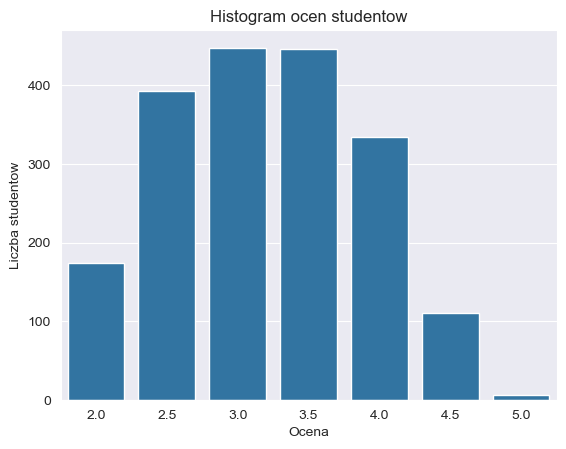

In [524]:
sns.countplot(x=y_train)
plt.xlabel('Ocena')
plt.ylabel('Liczba studentow')
plt.title('Histogram ocen studentow')
plt.show()

Widzimy ze mamy bardzo niezbalansowane dane

# Regresja liniowa


In [525]:
regresjaLiniowa = LinearRegression()
regresjaLiniowa.fit(X_train, y_train)

y_pred = regresjaLiniowa.predict(X_test)

print("r2", regresjaLiniowa.score(X_test, y_test))
print("mean absolute error", mean_absolute_error(y_test, y_pred))

r2 0.9125026639045141
mean absolute error 0.16476850386352118


In [526]:
print("Wyniki klasyfikacji")
print(classification_report(y_test, y_pred))


Wyniki klasyfikacji


ValueError: continuous is not supported

# Klasyfikacja
